# EDA — Amazon Product Dataset 2020

Exploratory pass over the raw Kaggle CSV before cleaning, to justify the choices baked into `src/ingestion/clean.py`: which columns are actually usable, and which category slice to index.

Run `python src/ingestion/download_data.py` first if `data/raw/*.csv` doesn't exist yet.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src" / "ingestion"))

import matplotlib.pyplot as plt
import pandas as pd

from config import RAW_DIR

csv_path = sorted(RAW_DIR.glob("*.csv"))[0]
raw = pd.read_csv(csv_path, low_memory=False)
raw.shape

(10002, 28)

## Column completeness

Several columns in this file exist but are entirely empty. This is what determines the hardcoded column list in `clean.py` and what the Answerer agent can/can't cite (e.g. brand, ingredients).

In [2]:
completeness = (raw.notna().mean() * 100).sort_values()
completeness

Product Description        0.000000
Stock                      0.000000
Size Quantity Variant      0.000000
Product Details            0.000000
Dimensions                 0.000000
Color                      0.000000
Quantity                   0.000000
Ingredients                0.000000
Asin                       0.000000
Brand Name                 0.000000
Direction To Use           0.000000
List Price                 0.000000
Sku                        0.000000
Upc Ean Code               0.339932
Product Dimensions         4.789042
Variants                  24.775045
Model Number              82.283543
Product Specification     83.683263
Shipping Weight           88.622276
Category                  91.701660
Technical Details         92.101580
About Product             97.270546
Selling Price             98.930214
Image                    100.000000
Product Name             100.000000
Is Amazon Seller         100.000000
Product Url              100.000000
Uniq Id                  100

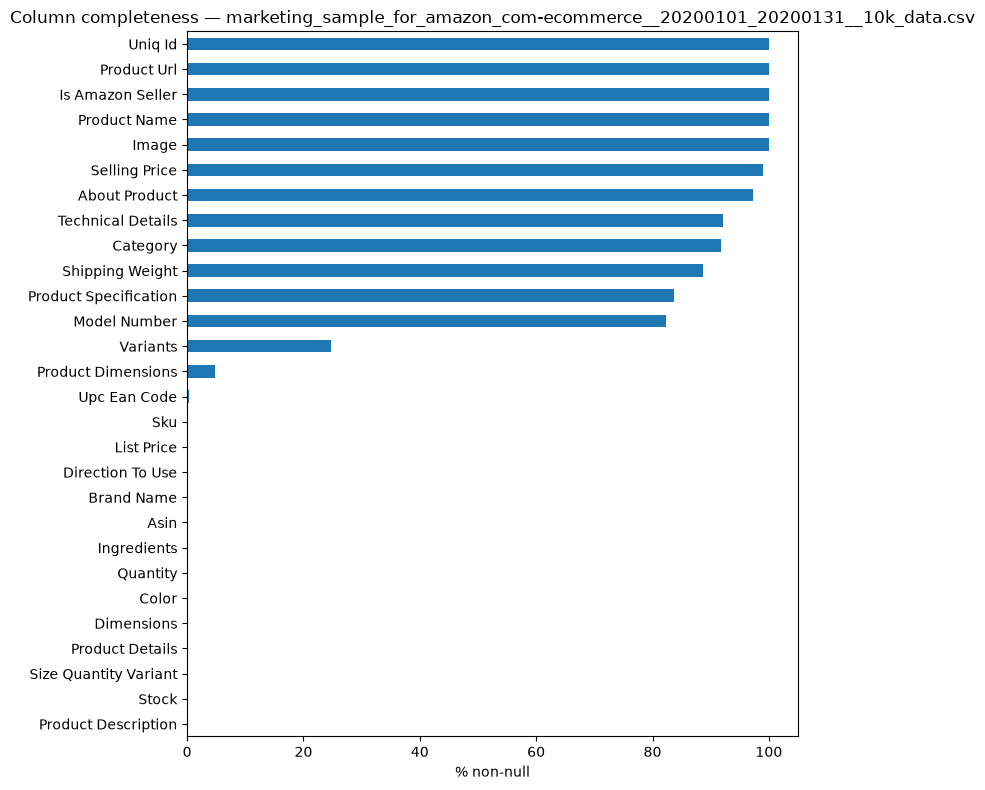

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
completeness.plot.barh(ax=ax)
ax.set_xlabel("% non-null")
ax.set_title(f"Column completeness — {csv_path.name}")
fig.tight_layout()

`Brand Name`, `Asin`, `Sku`, `Ingredients`, `Direction To Use`, `Product Details`, `Dimensions`, `Color`, `Size Quantity Variant`, `Product Description`, `Stock`, `Upc Ean Code` are effectively 0% populated. There is also **no rating or review-count column at all** — the schema targets in the project spec (`rating`) aren't recoverable from this file.

## Category distribution

`Category` is a `|`-delimited breadcrumb (e.g. `Home & Kitchen | Bedding | ...`). This checks whether the dataset actually supports a "Household Cleaning" slice, as the spec suggests.

In [4]:
top_level = raw["Category"].fillna("").str.split("|").str[0].str.strip()
top_level.value_counts().head(15)

Category
Toys & Games                                6662
                                             830
Home & Kitchen                               708
Clothing, Shoes & Jewelry                    630
Sports & Outdoors                            540
Baby Products                                214
Arts, Crafts & Sewing                        124
Office Products                               77
Hobbies                                       34
Industrial & Scientific                       29
Health & Household                            23
Remote & App Controlled Vehicle Parts         22
Tools & Home Improvement                      17
Remote & App Controlled Vehicles & Parts      17
Pet Supplies                                  16
Name: count, dtype: int64

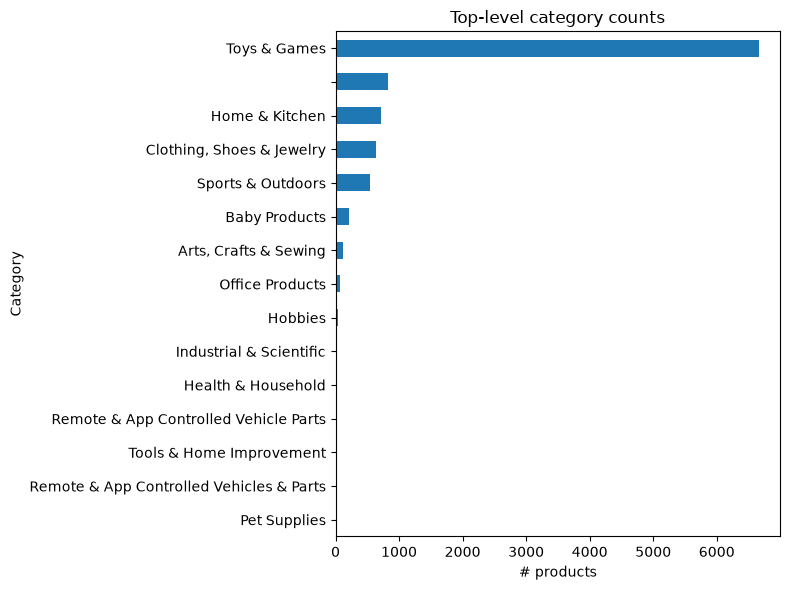

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
top_level.value_counts().head(15).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("# products")
ax.set_title("Top-level category counts")
fig.tight_layout()

In [6]:
cleaning_hits = raw["Category"].fillna("").str.lower().str.contains("clean").sum()
household_hits = (top_level == "Health & Household").sum()
print(f"rows with 'clean' anywhere in the category breadcrumb: {cleaning_hits}")
print(f"rows under top-level 'Health & Household': {household_hits}")

rows with 'clean' anywhere in the category breadcrumb: 7
rows under top-level 'Health & Household': 23


This dataset is a general marketplace sample dominated by Toys & Games, not a cleaning-focused scrape. `Health & Household` (and cleaning products specifically) is too thin to index. `Home & Kitchen` is the closest well-populated category to the product-discovery use case — that's what `CATEGORY_TOP_LEVEL` in `.env` is set to.

### Does a product ever belong to multiple categories?

Worth checking directly, since `_matches_category` in `clean.py` only looks at the *first* `|`-segment of `Category` — if a row's `Category` field ever packed together more than one independent category assignment, that filter would silently miss it.

In [7]:
cat = raw["Category"].dropna()

print("alternate delimiters that would indicate multiple category paths joined together:")
for delim in [",", ";", ">>", "||", "\n"]:
    print(f"  rows containing {delim!r}: {cat.str.contains(delim, regex=False).sum()}")

print("\nduplicate Uniq Id (same product filed under >1 category via repeated rows):",
      (raw["Uniq Id"].value_counts() > 1).sum())

print("\npipe-segment depth distribution (consistent with a single hierarchical breadcrumb):")
print(cat.str.count(r"\|").value_counts().sort_index())

alternate delimiters that would indicate multiple category paths joined together:
  rows containing ',': 1412
  rows containing ';': 0
  rows containing '>>': 0
  rows containing '||': 0
  rows containing '\n': 0

duplicate Uniq Id (same product filed under >1 category via repeated rows): 0

pipe-segment depth distribution (consistent with a single hierarchical breadcrumb):
Category
1    1086
2    3932
3    1811
4    1982
5     335
6      26
Name: count, dtype: int64


**Conclusion: no.** Every `Category` value is a single `|`-delimited breadcrumb (top level → leaf, 1–6 levels deep). There's no second delimiter joining independent category paths, and every `Uniq Id` is unique (no row-level duplication representing a second category assignment). The `,` that shows up in some rows is just part of a category *name* (e.g. `"Clothing, Shoes & Jewelry"`), not a separator between categories. Matching the top-level breadcrumb segment is therefore a correct 1:1 filter for this file — not an approximation of a many-to-many relationship. (A product can still be topically relevant to a category while filed under a different top-level, e.g. a kids' play-kitchen set under `Toys & Games` — that's a taxonomy/relevance tradeoff, not a parsing bug.)

## Price distribution

`Selling Price` is a `$`-prefixed string, so it needs parsing before any numeric analysis — same parser `clean.py` uses.

In [8]:
from clean import _parse_price

price = raw["Selling Price"].map(_parse_price)
price.describe()

count    9839.000000
mean       39.633625
std       132.908387
min         0.010000
25%         9.990000
50%        16.990000
75%        29.990000
max      5332.000000
Name: Selling Price, dtype: float64

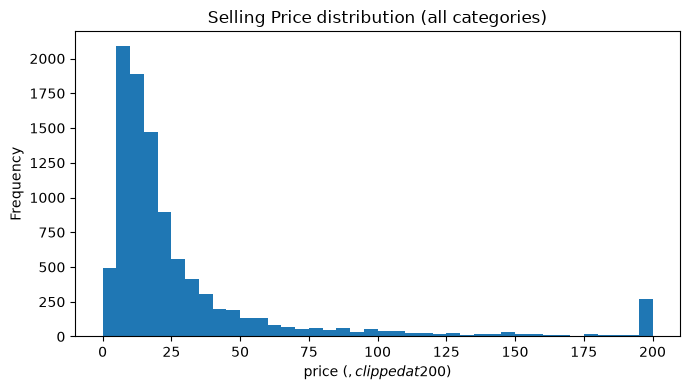

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
price.dropna().clip(upper=200).plot.hist(bins=40, ax=ax)
ax.set_xlabel("price ($, clipped at $200)")
ax.set_title("Selling Price distribution (all categories)")
fig.tight_layout()

## Zoom into the Home & Kitchen slice

In [10]:
hk = raw[top_level == "Home & Kitchen"].copy()
hk["sub_category"] = hk["Category"].str.split("|").str[1].str.strip()
print(f"rows: {len(hk)}")
hk["sub_category"].value_counts()

rows: 708


sub_category
Home Décor                199
Furniture                 196
Bedding                   177
Event & Party Supplies     72
Kitchen & Dining           53
Wall Art                    7
Seasonal Décor              2
Kids' Home Store            1
Storage & Organization      1
Name: count, dtype: int64

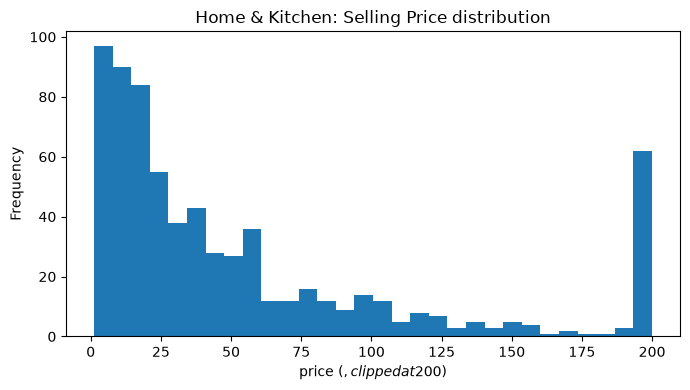

In [11]:
hk_price = hk["Selling Price"].map(_parse_price)
fig, ax = plt.subplots(figsize=(7, 4))
hk_price.dropna().clip(upper=200).plot.hist(bins=30, ax=ax)
ax.set_xlabel("price ($, clipped at $200)")
ax.set_title("Home & Kitchen: Selling Price distribution")
fig.tight_layout()

## Text length (for embedding-text sizing)

`build_index.py` embeds `title + features (About Product + Technical Details) + ingredients`. Checking that `About Product` actually carries enough signal to embed on. (`Product Specification` was considered too, but turned out to be near-100% boilerplate — see below — so `Technical Details` is used instead.)

In [12]:
about_len = hk["About Product"].fillna("").str.len()
about_len.describe()

count     708.000000
mean      442.727401
std       369.253133
min         0.000000
25%       209.750000
50%       312.000000
75%       565.250000
max      2262.000000
Name: About Product, dtype: float64

## Other gotchas worth flagging

Two more things found by inspecting raw values directly rather than trusting dtypes/completeness alone.

**1. `Selling Price` isn't always a clean `$X.XX` string.** ~4% of populated rows dataset-wide are garbage: `"from 2 sellers"`, `"Total price:"`, `"Currently unavailable."`, free-text shipping blurbs, or ranges like `"$8.25 - $31.95"`. An unanchored digit-extraction regex would misread `"from 2 sellers"` as `$2.00` — a real bug caught here. `_parse_price` requires the value to start with `$`.

In [13]:
sp = raw["Selling Price"].dropna().astype(str)
garbage = sp[~sp.str.match(r"^\$[\d,]+\.?\d*$")]
print(f"{len(garbage)} / {len(sp)} rows are not a clean \"$X.XX\" string")
garbage.value_counts().head(10)

385 / 9895 rows are not a clean "$X.XX" string


Selling Price
Total price:              42
$24.99 $24.99              8
Currently unavailable.     3
from 2 sellers             3
$14.99 $ 14 . 99           3
$8.25 - $31.95             2
$7.49 - $11.99             2
$9.99 $ 9 . 99             2
$61.81 - $9,999.99         2
$6.99 $ 6 . 99             2
Name: count, dtype: int64

**2. `Product Specification` is almost entirely boilerplate.** Every populated row follows the same template — `Shipping Weight: X (View shipping rates and policies)|ASIN: Y|#rank in Z` — with words run together (`ProductDimensions:5.7x4.9x1.2inches`, no spaces). It duplicates `Shipping Weight`/`Category` rank info already captured elsewhere and adds no free-text product description. `Technical Details` is used in `features` instead — genuine descriptive text, though it also carries its own recurring boilerplate (a return-policy blurb in ~43% of rows) that `clean.py` strips out.

## Takeaways for `clean.py` / `build_index.py`

- Hardcode real column names (`Uniq Id`, `Product Name`, `Brand Name`, `Category`, `Selling Price`, `About Product`, `Technical Details`, `Ingredients`, `Model Number`, `Shipping Weight`, `Product Url`) — no alias-guessing needed, this file's schema is fixed.
- `Brand Name` / `Ingredients` are unusable (0% populated) — retriever must return `None`, never fabricate.
- No rating column exists — `rating` is hardcoded to `None` in `clean.py`, not sourced.
- `Category` is a single breadcrumb per row, not a multi-category field — top-level exact match is a correct filter, not an approximation.
- `Selling Price` needs a `$`-anchored parser, not a bare digit-extraction regex, or garbage rows like `"from 2 sellers"` silently become fake prices.
- `Product Specification` is boilerplate; `Technical Details` is the real source of descriptive text for `features` (with its own boilerplate stripped).
- `Model Number` (82% populated) is captured as an extra identifier even though it's not part of the project spec's schema target.
- `CATEGORY_TOP_LEVEL=Home & Kitchen` gives 708 rows with usable price + description text; `Household Cleaning` does not exist as a usable slice in this file.